In [1]:
#%matplotlib qt
%matplotlib widget
import h5py
import numpy as np
from matplotlib import pyplot as plt
import hyperspy.api as hs
import pandas as pd

# Load data

In [2]:
file_path = h5py.File(r'E:\PSI\Experimental_data\STXM\Second_beamtime_02092022\Processed_data\LSCO_900C_12hrs\Raw_data\Sample_Stack_2022-09-12_016.hdf5', 'r')
data = file_path['entry1/counter0/data']


In [3]:
#Extraxt the step size indices in x and y dimensions of scan plus the step size indices in energy axis
energy_indices = file_path['entry1/counter0/energy'][:]
sample_y_indices = file_path['entry1/counter0/sample_y'][:]
sample_x_indices = file_path['entry1/counter0/sample_x'][:]

In [4]:
#Plot data

In [5]:
# Calculate step size in all axes
x_scale = (sample_x_indices.max()-sample_x_indices.min())/np.size(sample_x_indices)
y_scale = (sample_y_indices.max()-sample_y_indices.min())/np.size(sample_y_indices)
energy_scale= (energy_indices.max()-energy_indices.min())/np.size(energy_indices)

In [6]:
energy_scale

np.float64(0.19696969696969696)

In [7]:
s = hs.signals.Signal2D(data= data)
s

<Signal2D, title: , dimensions: (66|125, 125)>

In [8]:
#Navigation axis
s.axes_manager[0].name = 'Energy'
s.axes_manager[0].scale = energy_scale
s.axes_manager[0].units = 'eV'
s.axes_manager[0].offset = energy_indices[0]

#Signal axes
s.axes_manager[1].name = 'x'
s.axes_manager[1].scale = x_scale
s.axes_manager[1].offset = 0
s.axes_manager[1].units = 'µm'
s.axes_manager[2].name = 'y'
s.axes_manager[2].scale = y_scale
s.axes_manager[2].offset = 0
s.axes_manager[2].units = 'µm'

In [9]:
s.axes_manager[1].scale

0.03968000000000029

The widget matplotlib backend is not compatible with the traitsui GUI elements. For more information, read http://hyperspy.readthedocs.io/en/stable/user_guide/getting_started.html#possible-warnings-when-importing-hyperspy.


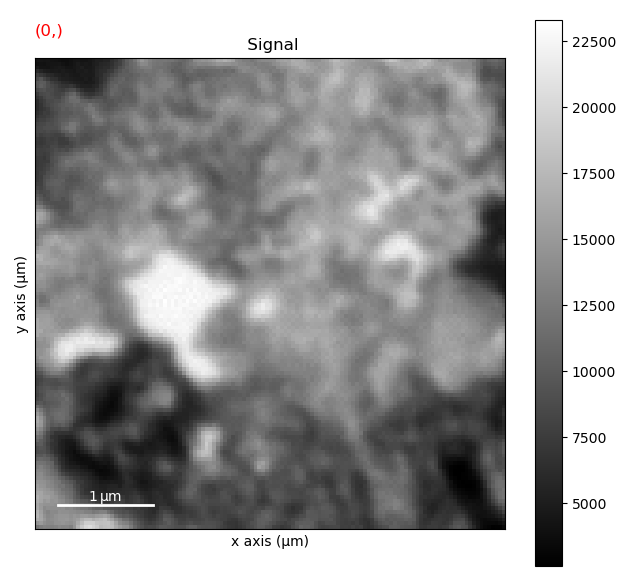

(0.0, 4.920320000000036)

In [10]:
s.plot(scalebar=True)
s.plot(navigator='slider')
plt.xlim(0,x_scale*np.size(sample_x_indices)-x_scale)
plt.ylim(0,x_scale*np.size(sample_x_indices)-x_scale)

# Image registration

In [11]:
shifts = s.estimate_shift2D(reference="cascade", sub_pixel_factor=20)

  0%|          | 0/66 [00:00<?, ?it/s]

Text(0, 0.5, 'y-shift')

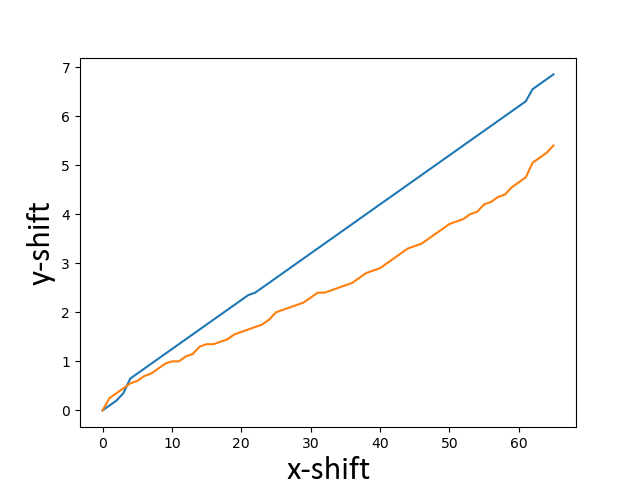

In [12]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp = np.arange(0,66,1)
plt.figure()
plt.plot( temp ,x_shift)
plt.xlabel('x-shift', fontname='Calibri', fontsize=24)
plt.plot( temp ,y_shift)
plt.ylabel('y-shift', fontname='Calibri', fontsize=24)

In [13]:
#Repeat until 'Zero' x and y shifts

In [20]:
s.align2D(shifts=shifts, parallel=True, max_workers=4)

  0%|          | 0/199 [00:00<?, ?it/s]

In [21]:
shifts = s.estimate_shift2D(reference="cascade", sub_pixel_factor=20)

  0%|          | 0/66 [00:00<?, ?it/s]

Text(0, 0.5, 'y-shift')

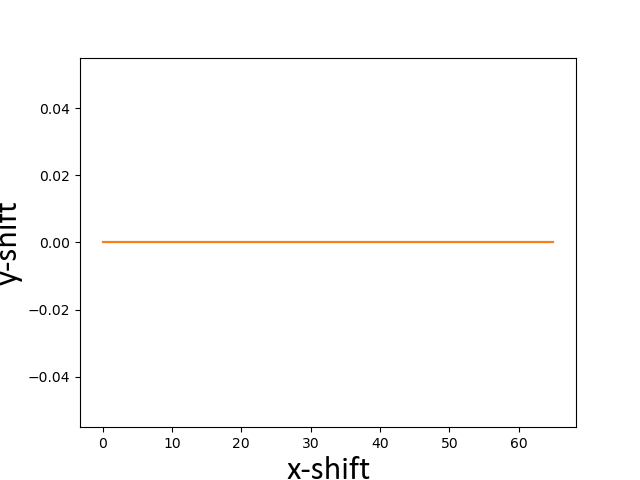

In [22]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp4 = np.arange(0,66,1)
plt.figure()
plt.plot( temp4 ,x_shift)
plt.xlabel('x-shift', fontname='Calibri', fontsize=24)
plt.plot( temp4 ,y_shift)
plt.ylabel('y-shift', fontname='Calibri', fontsize=24)

In [23]:
s

<Signal2D, title: , dimensions: (66|117, 116)>

In [24]:
x_dimension, y_dimension = 117,116

In [25]:
s.plot(scalebar=False)#navigator='slider'
plt.xlim( 0, x_dimension*x_scale )
plt.ylim( 0, y_dimension*y_scale)

(0.0, 4.602880000000034)

# Optical density

In [26]:
s1 =s.deepcopy()

In [27]:
s1 = s1.as_signal1D(('Energy'))

In [28]:
s1 = -(np.log(s1/s1.data.max()))

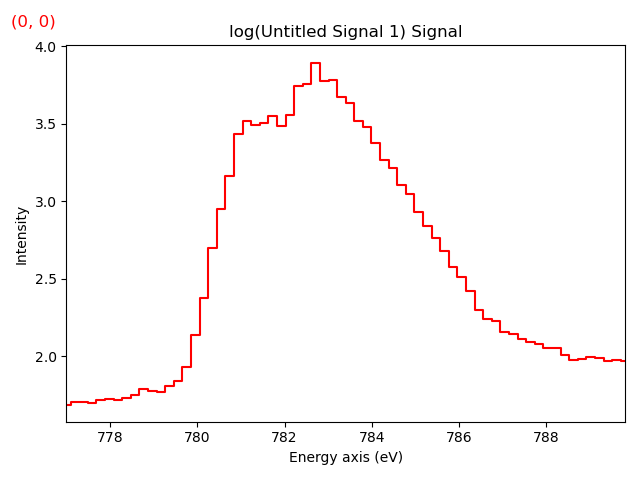

In [29]:
s1.plot(navigator='slider',drawstyle='default' )
s1.plot(scalebar = False)

# Sum spectrum

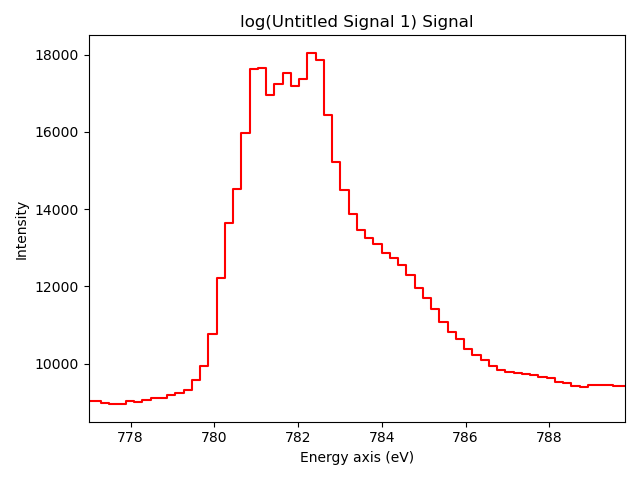

In [30]:
sum_spectrum = s1.sum()
sum_spectrum.plot()

In [31]:
# Save the sum_spectrum
x_scale = np.arange(777.0,790.1,0.2).astype(float)
np.savetxt('Sum_spectrum_900_12h.csv', np.column_stack((x_scale, sum_spectrum.data)), 
            delimiter=',', header='Energy (eV),Intensity (a.u.)', comments='')

# Data denoising

In [32]:
# Denoising/Identifying and  non-inclusion of vacuum pixels is required for efficient end-member calculation
#fit a line with the XAS spectrum. The noise has a good fit as compared to the spectra with high S/N ratio

In [33]:
x_scale = np.arange(777.0,790.1,0.2).astype(float)
s2 = s1.deepcopy()
s2 = s2.data.reshape(x_dimension*y_dimension, 66)
s2 = pd.DataFrame(s2)
s2.columns= x_scale

In [34]:
#can skip this cell

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# Initialize a list to store RMSE values
rmse_list = []

# Iterate over each row in the DataFrame
for index, row in s2.iterrows():

    y = row.values
    
    # Reshape index for sklearn compatibility
    x = np.arange(len(row)).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(x, y)
    
    # Predict y values
    y_pred = model.predict(x)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    # Append RMSE to the list
    rmse_list.append(rmse)

# Convert the list to a numpy array
rmse_array = np.array(rmse_list)

(-0.5, 115.5)

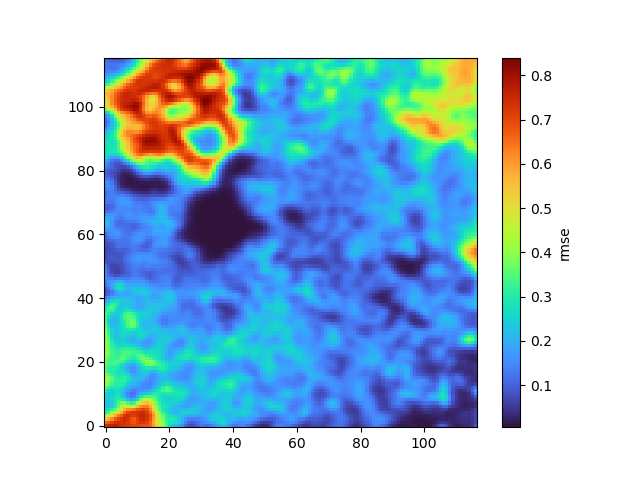

In [35]:
plt.figure()
data_rmse = rmse_array.reshape(y_dimension,x_dimension)

plt.imshow(data_rmse, cmap ='turbo')
plt.colorbar(label='rmse')
plt.xlim(-0.5, x_dimension-0.5)
plt.ylim(-0.5, y_dimension-0.5)

In [65]:
# Calculate the integrated area under each row
integrated_area = np.trapezoid(s2.values, axis=1,dx =0.2)

(-0.5, 115.5)

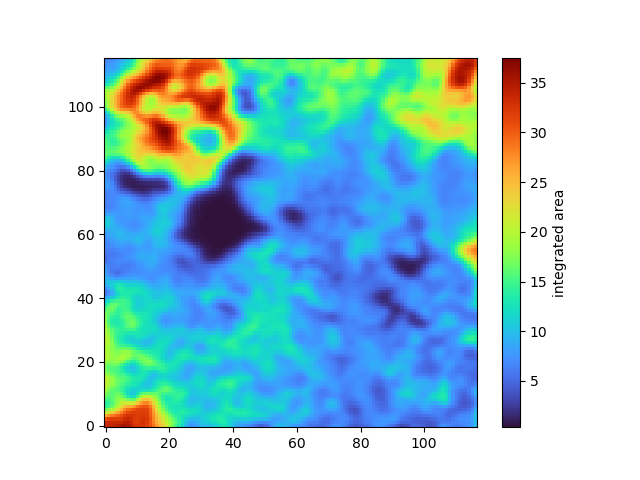

In [66]:
plt.figure()
data_area = integrated_area.reshape(y_dimension,x_dimension)

plt.imshow(data_area, cmap ='turbo')
plt.colorbar(label='integrated area')
plt.xlim(-0.5, x_dimension-0.5)
plt.ylim(-0.5, y_dimension-0.5)

In [39]:
s3 = s1.deepcopy()
s3 = s3.data.reshape(x_dimension*y_dimension, 66)

In [40]:
s3 = pd.DataFrame(s3)

In [41]:
s3.columns= x_scale

In [43]:

#Divide the filtered data by the integrated area for nnmf
s3_normalized = s3.div(integrated_area, axis=0)


In [44]:
s3_normalized = s3_normalized.values.reshape(y_dimension,x_dimension, 66)

In [45]:
s4 = s1.deepcopy()

In [46]:
s4.data = s3_normalized

In [47]:
s4.plot()###Normalized data

# Pixel brightness

(-0.5, 115.5)

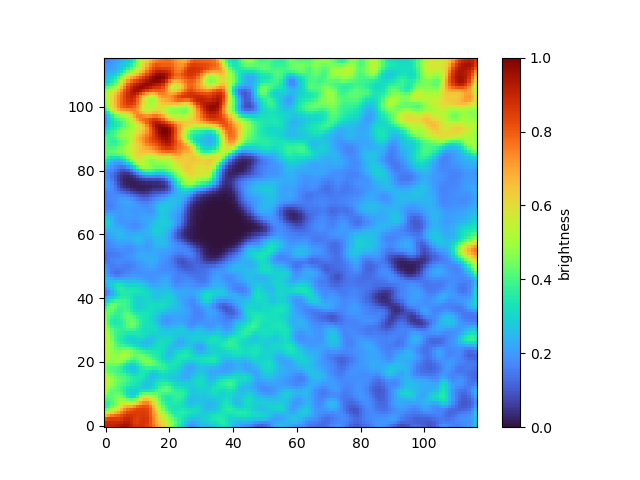

In [48]:
plt.figure()
brightness = (data_area - np.min(data_area)) / (np.max(data_area) - np.min(data_area))#normalized area between 0 and 1

plt.imshow(brightness, cmap ='turbo')
plt.colorbar(label='brightness')
plt.xlim(-0.5, x_dimension-0.5)
plt.ylim(-0.5, y_dimension-0.5)

# NNMF

In [49]:
#NMF
n_comp = 6
s4.decomposition( normalize_poissonian_noise=False,algorithm='NMF', output_dimension =n_comp, max_iter = 20000)

Decomposition info:
  normalize_poissonian_noise=False
  algorithm=NMF
  output_dimension=6
  centre=None
scikit-learn estimator:
NMF(max_iter=20000, n_components=6)


array([<Axes: title={'center': 'PC1'}, ylabel='Intensity'>,
       <Axes: title={'center': 'PC2'}, ylabel='Intensity'>,
       <Axes: title={'center': 'PC3'}, ylabel='Intensity'>,
       <Axes: title={'center': 'PC4'}, ylabel='Intensity'>,
       <Axes: title={'center': 'PC5'}, ylabel='Intensity'>,
       <Axes: title={'center': 'PC6'}, xlabel='Energy (eV)', ylabel='Intensity'>],
      dtype=object)

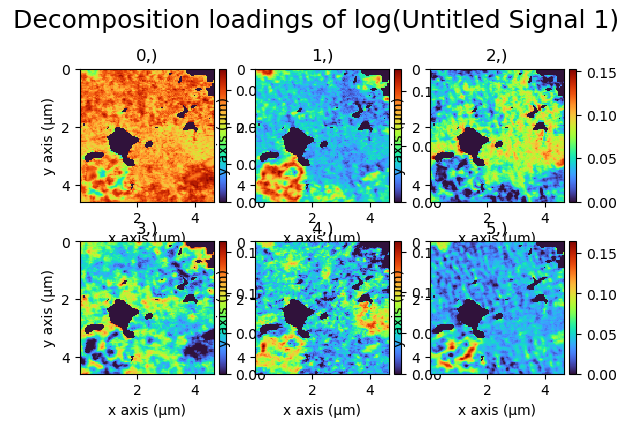

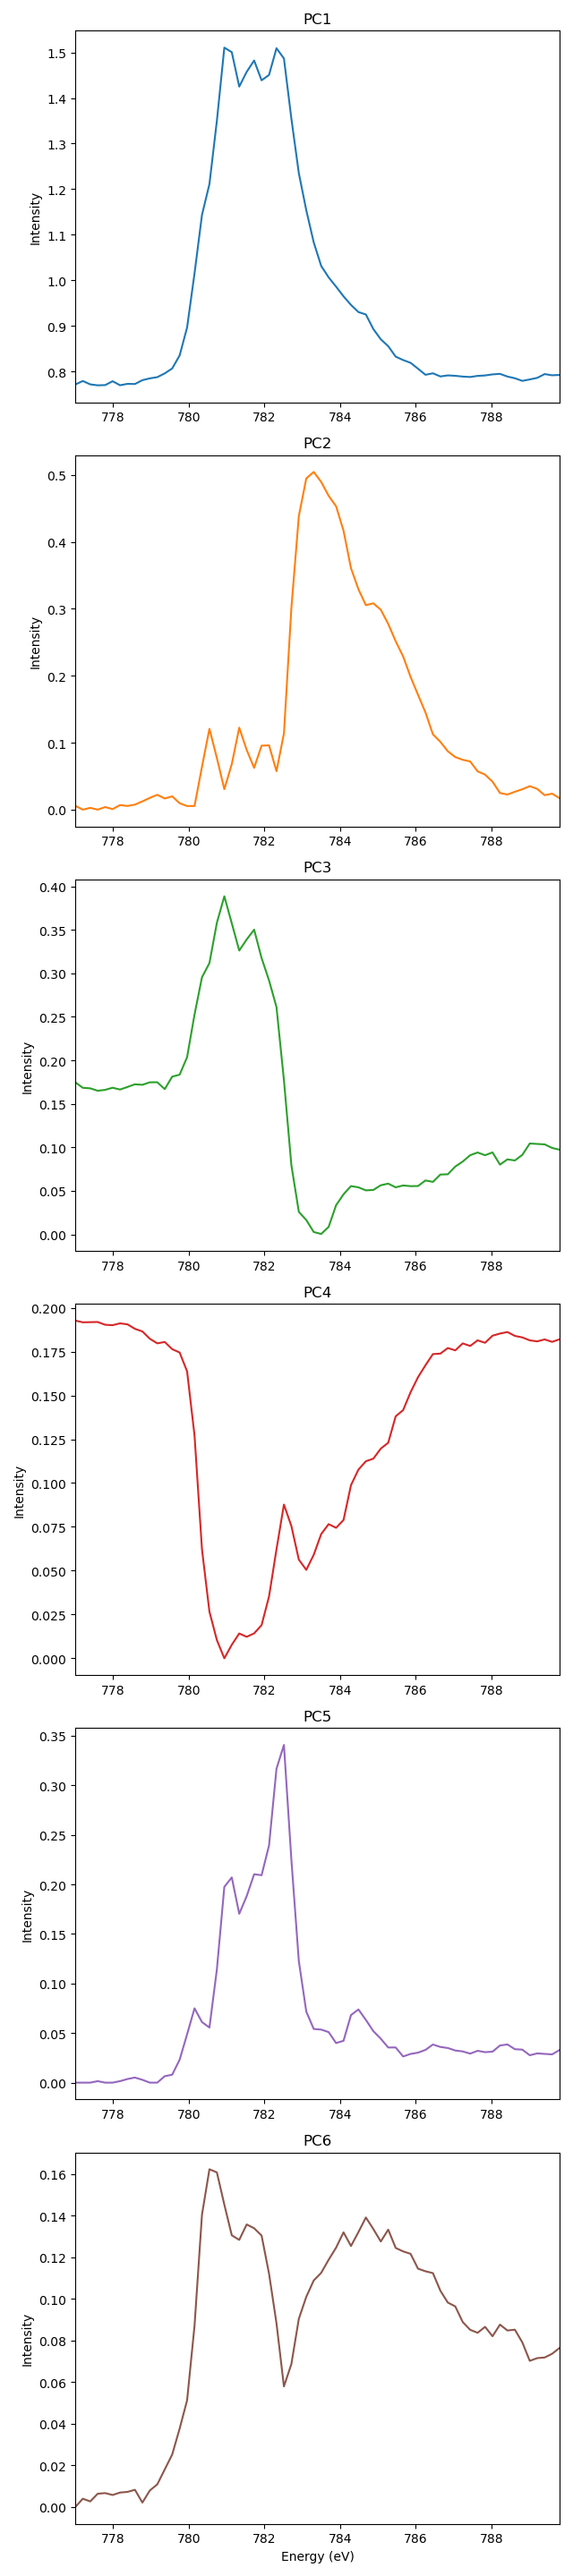

In [50]:
hs.plot.plot_images(s4.get_decomposition_loadings(), cmap='turbo')#Eigen images
hs.plot.plot_spectra(s4.get_decomposition_factors(),legend = ('PC1','PC2','PC3','PC4','PC5','PC6'),style='mosaic')#style='overlap' or 'cascade'#Eigen spectra

In [51]:
B = s4.get_decomposition_loadings()
print(B)

<BaseSignal, title: Decomposition loadings of log(Untitled Signal 1), dimensions: (6|117, 116)>


In [52]:
A = s4.get_decomposition_factors()
print(A)

<Signal1D, title: Decomposition factors of log(Untitled Signal 1), dimensions: (6|66)>


# NMF space map and end member

In [53]:
nmf_loadings = B.data.transpose(1, 2, 0).reshape(x_dimension*y_dimension, n_comp)

In [54]:
nmf_loadings.shape

(13572, 6)

In [55]:
#2d plot with circle patch

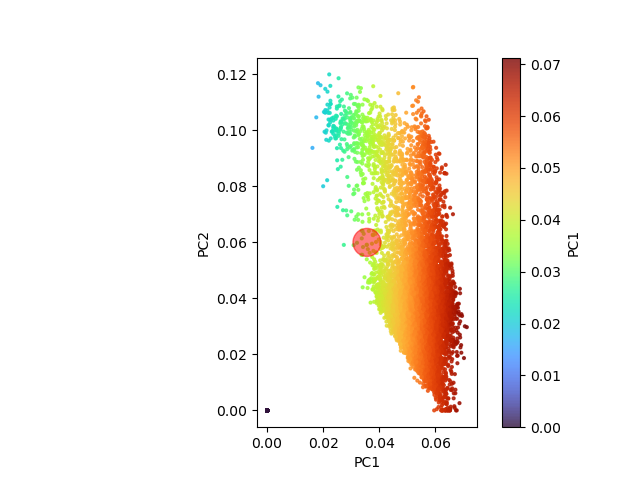

In [56]:
#Input what is PC1 and PC2

import matplotlib.pyplot as plt
from matplotlib.patches import Circle


x = nmf_loadings[:, 0]#PC1
y = nmf_loadings[:, 1]#PC2

s6 = s4.deepcopy()
s6 = s6.data.reshape(x_dimension * y_dimension, 66)

class DraggableCircle:
    def __init__(self, ax, center, radius, data):
        self.ax = ax
        self.circle = Circle(center, radius, color="r", alpha=0.5)
        self.ax.add_patch(self.circle)
        self.press = None
        self.center = center
        self.radius = radius
        self.data = data
        self.connect()

    def connect(self):
        self.cidpress = self.circle.figure.canvas.mpl_connect(
            'button_press_event', self.on_press)
        self.cidrelease = self.circle.figure.canvas.mpl_connect(
            'button_release_event', self.on_release)
        self.cidmotion = self.circle.figure.canvas.mpl_connect(
            'motion_notify_event', self.on_motion)

    def on_press(self, event):
        if event.inaxes != self.circle.axes:
            return
        contains, _ = self.circle.contains(event)
        if not contains:
            return
        self.press = event.xdata, event.ydata, self.center
        self.circle.set_alpha(1.0)
        self.circle.figure.canvas.draw()

    def on_motion(self, event):
        if self.press is None:
            return
        if event.inaxes != self.circle.axes:
            return
        xpress, ypress, (xcenter, ycenter) = self.press
        dx = event.xdata - xpress
        dy = event.ydata - ypress
        self.center = (xcenter + dx, ycenter + dy)
        self.circle.center = self.center
        self.circle.figure.canvas.draw()

    def on_release(self, event):
        self.press = None
        self.circle.set_alpha(0.5)
        self.circle.figure.canvas.draw()
        self.find_points_in_circle()

    def find_points_in_circle(self):
        indices = []
        for i, (x, y) in enumerate(self.data):
            if (x - self.center[0]) ** 2 + (y - self.center[1]) ** 2 <= self.radius ** 2:
                indices.append(i)
        #print("Indices of points within the circle:", indices)
        
        # Extract data from s6 using the indices found within the circle
        selected_data = s6[indices]
        
        # Calculate the average along the columns
        avg_data = np.average(selected_data, axis=0)
       
        # Define x-scale
        x_scale = np.arange(777.0, 790.1, 0.2)
        
        # Plot the sum
        
        fig, ax = plt.subplots()
        ax.plot(x_scale, avg_data)
        ax.set_title('End_member_spectrum')
        ax.set_xlabel('Energy(eV)')
        ax.set_ylabel('Intensity(a.u.)')
        plt.show()

        self.x_scale = x_scale
        self.avg_data = avg_data   
    
    def disconnect(self):
        self.circle.figure.canvas.mpl_disconnect(self.cidpress)
        self.circle.figure.canvas.mpl_disconnect(self.cidrelease)
        self.circle.figure.canvas.mpl_disconnect(self.cidmotion)


# Scatter plot
fig, ax = plt.subplots()
scatter = ax.scatter(x, y, s=4, c=x, cmap='turbo', alpha=0.8)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_aspect('equal')
cbar = plt.colorbar(scatter)
cbar.set_label('PC1')  


# Center coordinates and radius
x_center = min(x) + (max(x) - min(x)) / 2
y_center = min(y) + (max(y) - min(y)) / 2
circle_radius = 0.005

# Add draggable circle
draggable_circle = DraggableCircle(ax, (x_center, y_center), circle_radius, list(zip(x, y)))

plt.show()


In [ ]:
# Save the end-member data (Co3+)
end_member_scale = draggable_circle.x_scale
end_member_data = draggable_circle.avg_data
np.savetxt('end_member_spectrum1_noise_filtered.csv', np.column_stack((end_member_scale, end_member_data)), 
            delimiter=',', header='Energy (eV),Intensity (a.u.)', comments='')

In [ ]:
# Save the end-member data (Co2+)
end_member_scale = draggable_circle.x_scale
end_member_data = draggable_circle.avg_data
np.savetxt('end_member_spectrum2_noise_filtered.csv', np.column_stack((end_member_scale, end_member_data)), 
            delimiter=',', header='Energy (eV),Intensity (a.u.)', comments='')

# NNLR fitting

In [ ]:
#End-members_normalized

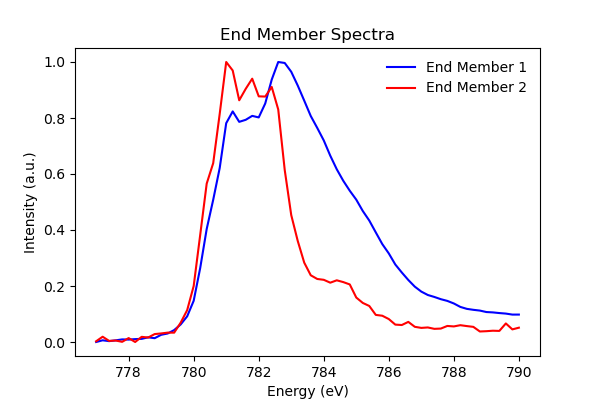

In [57]:
end_member1 = np.loadtxt('end_member_spectrum1_noise_filtered.csv', delimiter=',', skiprows=1)  # Assuming the first row is header
end_member2 = np.loadtxt('end_member_spectrum2_noise_filtered.csv', delimiter=',', skiprows=1)


x_scale = end_member1[:, 0]  
y1 = end_member1[:, 1]  #Co3+
y2 = end_member2[:, 1]  #Co2+

# Normalize intensity data
y1_normalized = (y1 - np.min(y1)) / (np.max(y1) - np.min(y1))
y2_normalized = (y2 - np.min(y2)) / (np.max(y2) - np.min(y2))

plt.figure(figsize = (6,4))
plt.plot(x_scale, y1_normalized, label='End Member 1', color='blue')
plt.plot(x_scale, y2_normalized, label='End Member 2', color='red')
plt.xlabel('Energy (eV)')
plt.ylabel('Intensity (a.u.)')
plt.title('End Member Spectra')
plt.legend(frameon = False)
plt.show()


In [58]:
#fitting

In [59]:
from scipy.optimize import minimize
import numpy as np

# Define the least squares loss function WITHOUT min-max normalization
def least_squares_loss(weights, x_data, y1_data, y2_data):
    # Calculate predicted values using the weights
    predicted_values = weights[0] * y1_data + weights[1] * y2_data
    
    # Calculate squared difference between predicted and actual values
    loss = np.sum((x_data - predicted_values)**2)
    
    return loss

# Define the constraint function
def constraint_func(weights):
    return weights

# Load dataset. s4.data is ALREADY area-normalized.
dataset = s4.data.reshape(x_dimension * y_dimension, 66)

# DO NOT normalize y1 and y2 arrays separately. Use them as-is.
y1_fitting = y1
y2_fitting = y2

# Fitting weights for each row
fitting_weights = []
rmse_values = []

# Iterate over each row of the dataset## each row is a spectrum
for row in dataset:
    # Define initial guess for weights
    initial_weights = np.array([0.5, 0.5])  # Equal weights initially
    
    # Define constraints for weights
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},  # Constraint: sum of weights equals 1
                   {'type': 'ineq', 'fun': lambda w: w})  # Constraint: weights must be non-negative
    
    # Optimize fitting weights using least squares loss function
    result = minimize(least_squares_loss, initial_weights, args=(row, y1_fitting, y2_fitting),
                      constraints=constraints)
    
    # Append fitting weights to list
    fitting_weights.append(result.x)
    
    # Calculate RMSE WITHOUT min-max normalization
    predicted_values = result.x[0] * y1_fitting + result.x[1] * y2_fitting
    rmse = np.sqrt(np.mean((row - predicted_values)**2))
    rmse_values.append(rmse)

# Convert fitting weights list to numpy array
fitting_weights = np.array(fitting_weights)

# Ensure sum of weights for each row is between 0 and 1
fitting_weights = np.clip(fitting_weights, 0, 1)

# Convert rmse_values list to numpy array
rmse_values = np.array(rmse_values)

# Print or use fitting weights for further analysis
print("Fitting weights shape:", fitting_weights.shape)
print("RMSE values shape:", rmse_values.shape)

Fitting weights shape: (13572, 2)
RMSE values shape: (13572,)


# STXM map

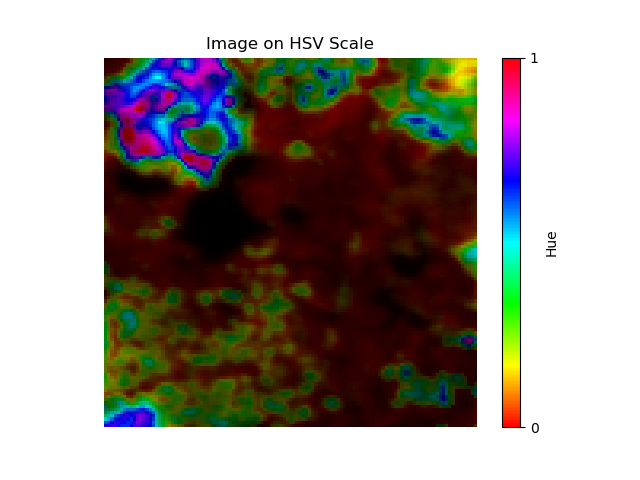

In [67]:
import matplotlib.colors as mcolors

# Define custom colormap based on HSV
def hsv_colormap(h):
    hsv_colors = np.ones((h.size, 3))
    hsv_colors[:, 0] = h
    hsv_colors[:, 1:] = 1.0
    return mcolors.hsv_to_rgb(hsv_colors)

hues = np.linspace(0, 1, 256)
hsv_cmap = mcolors.ListedColormap(hsv_colormap(hues))

# Define HSV array using pc1_fit for hue, saturation of 1, and brightness for value
hsv = np.zeros((y_dimension, x_dimension, 3))
hsv[:, :, 0] = pc1_fit  # Hue (using pc1_fit)
hsv[:, :, 1] = 1.0  # Saturation (constant value of 1)
hsv[:, :, 2] = brightness  # Brightness (using brightness)

# Convert HSV array to RGB
rgb_image = mcolors.hsv_to_rgb(hsv)

# Get the minimum and maximum hue values for setting colorbar limits
min_hue = np.min(pc1_fit)
max_hue = np.max(pc1_fit)

# Plot the RGB image with the custom colormap
plt.figure()
plt.imshow(rgb_image, cmap=hsv_cmap, vmin=min_hue, vmax=max_hue)
cbar = plt.colorbar(label='Hue')
cbar.set_ticks([min_hue, max_hue])  # Set colorbar ticks to match hue range
plt.axis('off')  # Turn off axis
plt.title('Image on HSV Scale')
plt.xlim(-0.5, x_dimension - 0.5)
plt.ylim(-0.5, y_dimension - 0.5)
plt.show()


In [ ]:
#hue 0.67

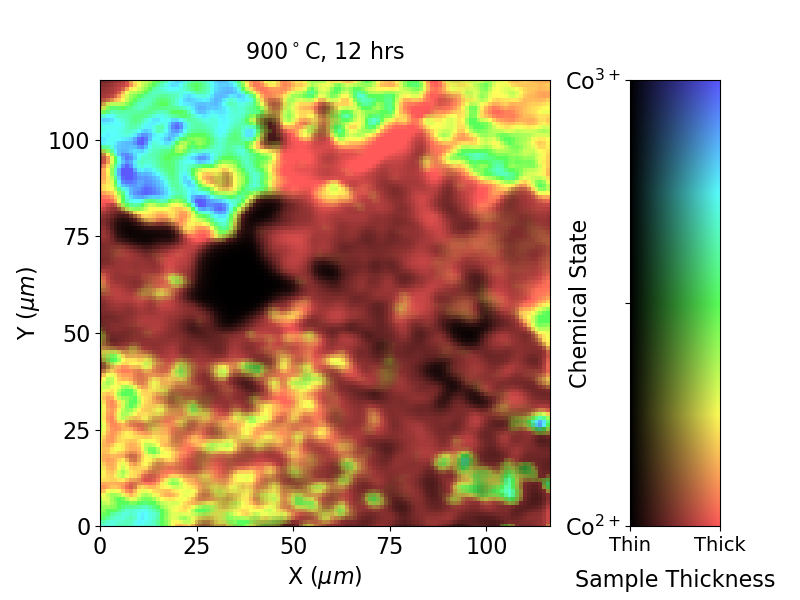

In [73]:
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 1. Define HSV array for the main image
hsv = np.zeros((y_dimension, x_dimension, 3))

# Hue: map fitting weights to 0.0 - 0.67 range
scaled_pc1_fit = pc1_fit * 0.67
hsv[:, :, 0] = scaled_pc1_fit 

# Saturation
saturation_val = 0.65  # adjust
hsv[:, :, 1] = saturation_val 

# Value (Brightness): modulate by sample thickness
brightness_factor = 3  # Adjust
adjusted_brightness = np.clip(brightness * brightness_factor, 0, 1)
hsv[:, :, 2] = adjusted_brightness 

# Convert HSV array to RGB for the actual image
rgb_image = mcolors.hsv_to_rgb(hsv)

# Plot the main image
fig, ax = plt.subplots(figsize=(8, 6))
img = ax.imshow(rgb_image)

# Add axes formatting and labels for the main map
x_ticks = np.arange(0, 126, 25)  
y_ticks = np.arange(0, 126, 25)  
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.tick_params(labelsize=16)
ax.set_xlabel("X ($\mu m$)", fontsize=16)  
ax.set_ylabel("Y ($\mu m$)", fontsize=16) 
ax.set_xlim(0, x_dimension - 0.5)
ax.set_ylim(0, y_dimension - 0.5)
ax.set_title(r'900$^\circ$C, 12 hrs', fontsize=16, pad=15)


# Create an attached axes on the right side of the main plot
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="20%", pad=0.8) # Increased pad slightly for y-labels

# Generate a 2D grid for the legend (200x200 pixels)
res = 200
x_val = np.linspace(0, 1, res) # Represents brightness (0 to 1) -> Thin to Thick
y_val = np.linspace(0, 1, res) # Represents pc1_fit (0 to 1) -> Co2+ to Co3+
X, Y = np.meshgrid(x_val, y_val)

# Populate the HSV array for the legend
hsv_leg = np.zeros((res, res, 3))
hsv_leg[:, :, 0] = Y * 0.67       # Hue (Y-axis): Red at bottom, Blue at top
hsv_leg[:, :, 1] = saturation_val # Saturation: matched to main map
hsv_leg[:, :, 2] = X              # Value (X-axis): Dark on left, Bright on right

# Convert to RGB
rgb_leg = mcolors.hsv_to_rgb(hsv_leg)

# Plot the 2D legend
# origin='lower' ensures Y=0 (Co2+) is at the bottom.
cax.imshow(rgb_leg, origin='lower', extent=[0, 1, 0, 1], aspect='auto')

# Formatting the X-axis (Thickness)
cax.set_xticks([0, 1])
cax.set_xticklabels(['Thin', 'Thick'], fontsize=14)
cax.set_xlabel('Sample Thickness', fontsize=16, labelpad=10)

# Formatting the Y-axis (Chemistry)
cax.set_yticks([0, 0.5, 1])
cax.set_yticklabels(['Co$^{2+}$', '', 'Co$^{3+}$'], fontsize=16)
cax.set_ylabel('Chemical State', fontsize=16, labelpad=-20)

plt.show()

In [ ]:
fig.savefig('STXM_hue0.67_brightness3.png', dpi = 1200, bbox_inches='tight')

# La map

In [ ]:
file_path1 = h5py.File(r'C:\Storage\Studies\Experimental_data\STXM\Second_beamtime_02092022\Processed_data\LSCO_900C_12hrs\Raw_data\Sample_Image_2022-09-12_020.hdf5', 'r')
data1 = file_path1['entry1/counter0/data']
###777 eV

In [ ]:
file_path2 = h5py.File(r'C:\Storage\Studies\Experimental_data\STXM\Second_beamtime_02092022\Processed_data\LSCO_900C_12hrs\Raw_data\Sample_Image_2022-09-12_018.hdf5', 'r')
data2 = file_path2['entry1/counter0/data']
###837 eV

In [ ]:
signal1 = hs.signals.Signal2D(data1)
signal2 = hs.signals.Signal2D(data2)

In [ ]:
signal1 = -np.log(signal1/signal1.data.max())
signal2 = -np.log(signal2/signal2.data.max())

In [ ]:
stack = hs.stack((signal1,signal2))

In [ ]:
stack.plot(scalebar=False)#navigator='slider'

plt.xlim(-0.5, 124.5)
plt.ylim(-0.5, 124.5)

In [ ]:
shifts = stack.estimate_shift2D(reference="cascade", sub_pixel_factor=20)

In [ ]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp4 = np.arange(0,2,1)
plt.figure()
plt.plot( temp4 ,x_shift)
plt.plot( temp4 ,y_shift)

In [ ]:
stack.align2D(shifts=shifts, parallel=True, max_workers=4)

In [ ]:
shifts = stack.estimate_shift2D(reference="cascade", sub_pixel_factor=20)  ##Estimate shifts with a sub-pixel accuracy of 1/sub_pixel_factor parts of a pixel. 
#Default is 1, i.e. no sub-pixel accuracy.

In [ ]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp4 = np.arange(0,2,1)
plt.figure()
plt.plot( temp4 ,x_shift)
plt.plot( temp4 ,y_shift)

In [ ]:
stack.plot(scalebar=False)#navigator='slider'

plt.xlim(-0.5, 124.5)
plt.ylim(-0.5, 124.5)

In [ ]:
La_map  = stack.inav[1]-stack.inav[0]

In [ ]:
La_map.plot(scalebar = False)
plt.xlim(-0.5, 124.5)
plt.ylim(-0.5, 124.5)

# Co map

In [ ]:
signal3 = s.inav[0]
signal4 = s.inav[28]

In [ ]:
signal3 = -np.log(signal3/signal3.data.max())
signal4 = -np.log(signal4/signal4.data.max())

In [ ]:
stack2 = hs.stack((signal3,signal4))

In [ ]:
stack2.plot(scalebar=False)#navigator='slider'
plt.xlim(0,x_scale*np.size(sample_x_indices)-x_scale)
plt.ylim(0,x_scale*np.size(sample_x_indices)-x_scale)

In [ ]:
shifts = stack2.estimate_shift2D(reference="cascade", sub_pixel_factor=20)

In [ ]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp4 = np.arange(0,2,1)
plt.figure()
plt.plot( temp4 ,x_shift)
plt.plot( temp4 ,y_shift)

In [ ]:
stack2.align2D(shifts=shifts, parallel=True, max_workers=4)

In [ ]:
shifts = stack2.estimate_shift2D(reference="cascade", sub_pixel_factor=20)

In [ ]:
x_shift = shifts[:,0:1]
y_shift = shifts[:,1:2]
temp4 = np.arange(0,2,1)
plt.figure()
plt.plot( temp4 ,x_shift)
plt.plot( temp4 ,y_shift)

In [ ]:
Co_map  = stack2.inav[1]-stack2.inav[0]

In [ ]:
Co_map.plot(scalebar = False)
plt.xlim(0,x_scale*np.size(sample_x_indices)-x_scale)
plt.ylim(0,x_scale*np.size(sample_x_indices)-x_scale)